In [28]:
# import all libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

from pathlib import Path

import joblib

import warnings
warnings.filterwarnings("ignore")

In [29]:
# project path
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

MODELS_PATH = PROJECT_ROOT / "models"

ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"

MODELS_PATH.mkdir(exist_ok=True)

ARTIFACTS_PATH.mkdir(exist_ok=True)

In [30]:
# load dataset
hotel_df = pd.read_csv(
    RAW_DATA_PATH / "hotels.csv"
)

hotel_df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [31]:
# /dataset overview
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


In [32]:
hotel_df.describe(include="all")

,travelCode,userCode,name,place,days,price,total,date
count,40552.000000,40552.000000,40552,40552,40552.000000,40552.000000,40552.000000,40552
unique,NaN,NaN,9,9,NaN,NaN,NaN,199
top,NaN,NaN,Hotel K,Salvador (BH),NaN,NaN,NaN,10/03/2019
freq,NaN,NaN,5094,5094,NaN,NaN,NaN,404
mean,67911.794461,666.963726,NaN,NaN,2.499679,214.439554,536.229513,NaN
std,39408.199333,391.136794,NaN,NaN,1.119326,76.742305,319.331482,NaN
min,0.000000,0.000000,NaN,NaN,1.000000,60.390000,60.390000,NaN
25%,33696.750000,323.000000,NaN,NaN,1.000000,165.990000,247.620000,NaN
50%,67831.000000,658.000000,NaN,NaN,2.000000,242.880000,495.240000,NaN
75%,102211.250000,1013.000000,NaN,NaN,4.000000,263.410000,742.860000,NaN


In [33]:
hotel_df.shape

(40552, 8)

In [34]:
hotel_df.columns

Index(['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total',
       'date'],
      dtype='object')

In [35]:
# missing values
hotel_df.isnull().sum()

travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

In [36]:
# duplicate records
hotel_df.duplicated().sum()

np.int64(0)

In [37]:
# convert date
hotel_df["date"] = pd.to_datetime(
    hotel_df["date"]
)

In [38]:
# extract all date info
hotel_df["year"] = hotel_df["date"].dt.year

hotel_df["month"] = hotel_df["date"].dt.month

hotel_df["day"] = hotel_df["date"].dt.day

hotel_df["weekday"] = hotel_df["date"].dt.day_name()

In [39]:
# verify it 
hotel_df.head()

,travelCode,userCode,name,place,days,price,total,date,year,month,day,weekday
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26,2019,9,26,Thursday
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10,2019,10,10,Thursday
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,2019-11-14,2019,11,14,Thursday
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,2019-12-12,2019,12,12,Thursday
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,2019-12-26,2019,12,26,Thursday


In [40]:
# EDA
# TOTAL USERS
hotel_df["userCode"].nunique()

1310

In [41]:
# total hotels
hotel_df["name"].nunique()

9

In [42]:
# total places
hotel_df["place"].nunique()

9

In [43]:
# hotel booking counts
hotel_df["name"].value_counts()

name
Hotel K     5094
Hotel CB    5029
Hotel BD    4829
Hotel AF    4828
Hotel AU    4467
Hotel BP    4437
Hotel BW    4333
Hotel Z     4205
Hotel A     3330
Name: count, dtype: int64

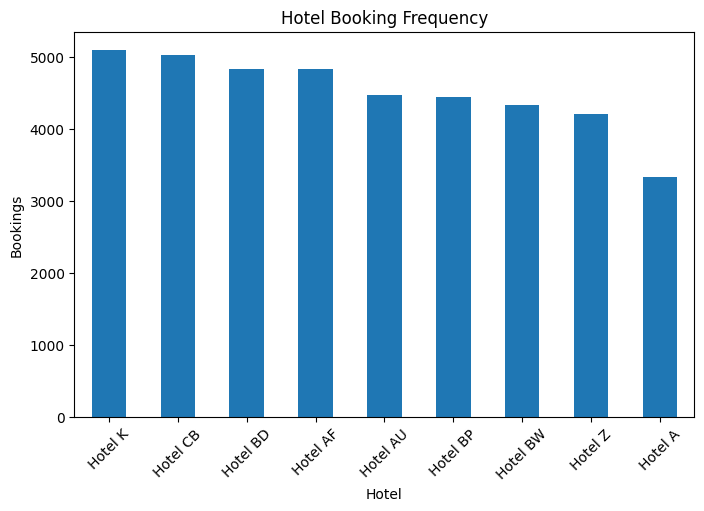

In [44]:
# most popular hotels
plt.figure(figsize=(8,5))

hotel_df["name"].value_counts().plot.bar()

plt.title("Hotel Booking Frequency")

plt.xlabel("Hotel")

plt.ylabel("Bookings")

plt.xticks(rotation=45)

plt.show()

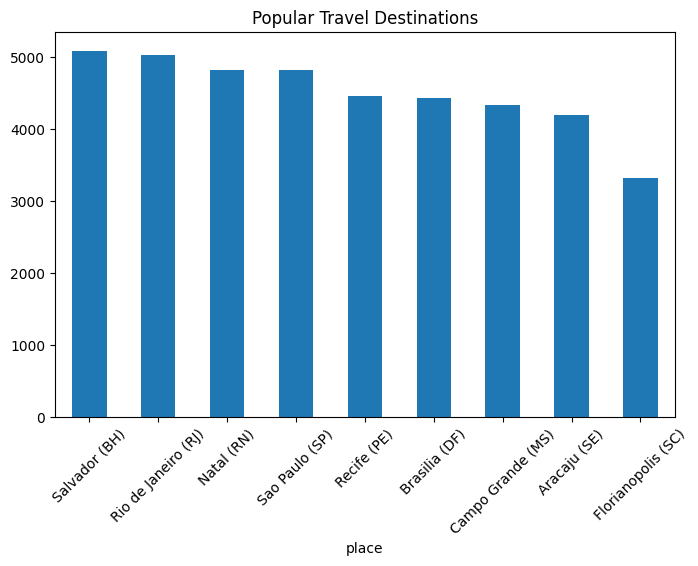

In [45]:
# most popular places
plt.figure(figsize=(8,5))

hotel_df["place"].value_counts().plot.bar()

plt.title("Popular Travel Destinations")

plt.xticks(rotation=45)

plt.show()

In [46]:
# avg hotels price
hotel_df.groupby("name")["price"].mean()

name
Hotel A     313.02
Hotel AF    139.10
Hotel AU    312.83
Hotel BD    242.88
Hotel BP    247.62
Hotel BW     60.39
Hotel CB    165.99
Hotel K     263.41
Hotel Z     208.04
Name: price, dtype: float64

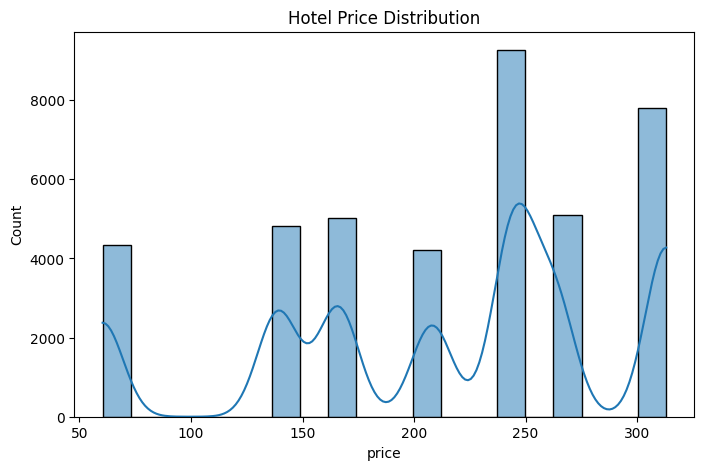

In [47]:
# price distribution
plt.figure(figsize=(8,5))

sns.histplot(
    hotel_df["price"],
    bins=20,
    kde=True
)

plt.title("Hotel Price Distribution")

plt.show()

In [48]:
# booking month
hotel_df["month"].value_counts().sort_index()

month
1     3775
2     3284
3     3380
4     3576
5     2871
6     2858
7     3079
8     2528
9     3011
10    4504
11    3634
12    4052
Name: count, dtype: int64

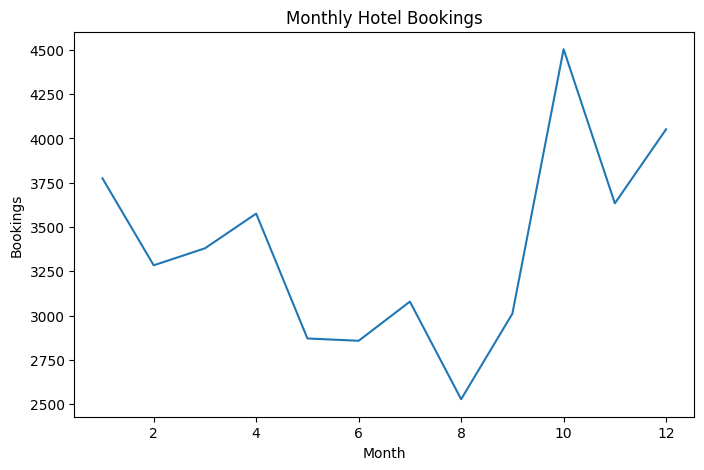

In [49]:
# monthly booking trend
plt.figure(figsize=(8,5))

hotel_df["month"].value_counts().sort_index().plot()

plt.title("Monthly Hotel Bookings")

plt.xlabel("Month")

plt.ylabel("Bookings")

plt.show()

Create User-Hotel Interaction Matrix

This is the heart of collaborative filtering.

Each row = User

Each column = Hotel

Each value = Number of bookings

In [50]:
# Create User-Hotel Matrix

user_hotel_matrix = pd.pivot_table(
    hotel_df,
    index="userCode",
    columns="name",
    values="travelCode",
    aggfunc="count",
    fill_value=0
)

user_hotel_matrix.head()

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,3,4,2,4,1,2,1,7,3
1,0,1,0,0,1,0,0,0,0
2,6,2,3,2,2,7,3,5,6
3,10,6,7,11,2,9,7,6,2
4,7,6,7,5,3,6,11,7,4


In [51]:
# check matrix shape
print(user_hotel_matrix.shape)

(1310, 9)


In [52]:
# Visualize Matrix
user_hotel_matrix.head(10)

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,3,4,2,4,1,2,1,7,3
1,0,1,0,0,1,0,0,0,0
2,6,2,3,2,2,7,3,5,6
3,10,6,7,11,2,9,7,6,2
4,7,6,7,5,3,6,11,7,4
5,1,3,0,1,0,1,1,5,1
6,4,5,1,3,3,1,3,3,0
7,0,1,2,3,1,5,1,0,1
8,6,4,8,12,4,6,4,3,5


In [53]:
# Compute User Similarity
user_similarity = cosine_similarity(
    user_hotel_matrix
)

In [54]:
# convert into dataframe
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_hotel_matrix.index,
    columns=user_hotel_matrix.index
)

user_similarity_df.head()

userCode,0,1,2,3,4,5,6,7,8,9,...,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339
userCode,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.338643,0.808627,0.817538,0.805124,0.920250,0.808229,0.517285,0.775270,0.789883,...,0.705327,0.691148,0.813617,0.799943,0.312825,0.727077,0.095783,0.794256,0.095783,0.818854
1,0.338643,1.000000,0.213201,0.258199,0.322252,0.339683,0.636446,0.218218,0.297318,0.346410,...,0.473365,0.744092,0.477334,0.444500,0.866025,0.449977,0.707107,0.308607,0.707107,0.442326
2,0.808627,0.213201,1.000000,0.842925,0.858804,0.663856,0.678454,0.697863,0.788392,0.910877,...,0.711039,0.645895,0.809904,0.764912,0.276956,0.781188,0.150756,0.657952,0.150756,0.817303
3,0.817538,0.258199,0.842925,1.000000,0.917567,0.635867,0.842189,0.767682,0.935599,0.816165,...,0.663889,0.638125,0.760024,0.782892,0.316776,0.757268,0.091287,0.737058,0.091287,0.761387
4,0.805124,0.322252,0.858804,0.917567,1.000000,0.697323,0.848869,0.648517,0.838347,0.847571,...,0.711865,0.723160,0.791897,0.823067,0.392777,0.902259,0.151911,0.707193,0.151911,0.781332


In [55]:
# find similar users
def find_similar_users(user_id, top_n=5):

    similar_users = (
        user_similarity_df[user_id]
        .sort_values(ascending=False)
    )

    similar_users = similar_users.iloc[1:top_n+1]

    return similar_users

In [56]:
# test
find_similar_users(10)

userCode
398    0.951751
686    0.946262
789    0.938627
38     0.934130
171    0.925227
Name: 10, dtype: float64

In [57]:
# recommendation function
def recommend_hotels(user_id, top_n=5):

    # Hotels already booked
    booked = user_hotel_matrix.loc[user_id]

    booked_hotels = booked[
        booked > 0
    ].index.tolist()

    # Similar Users
    similar_users = find_similar_users(
        user_id,
        top_n=10
    ).index

    recommendations = []

    for user in similar_users:

        hotels = user_hotel_matrix.loc[user]

        hotels = hotels[
            hotels > 0
        ].index.tolist()

        recommendations.extend(hotels)

    recommendations = list(
        set(recommendations)
    )

    recommendations = [
        hotel
        for hotel in recommendations
        if hotel not in booked_hotels
    ]

    return recommendations[:top_n]

In [58]:
# /test recommendation
recommend_hotels(25)

[]

In [59]:
user_id = 25

print(f"Recommended Hotels for User {user_id}")

for hotel in recommend_hotels(user_id):

    print("•", hotel)

Recommended Hotels for User 25


In [60]:
# evaluate recommendation system
recommendation_results = []

for user in user_hotel_matrix.index:

    recommendation_results.append(

        len(
            recommend_hotels(user)
        )

    )

print("Average Recommendations :")

print(np.mean(recommendation_results))

Average Recommendations :
1.3030534351145038


In [61]:
# Recommendation Coverage
recommended_hotels = set()

for user in user_hotel_matrix.index:

    recommended_hotels.update(

        recommend_hotels(user)

    )

coverage = (

    len(recommended_hotels)

    /

    hotel_df["name"].nunique()

)

print("Recommendation Coverage :")

print(round(coverage,3))

Recommendation Coverage :
1.0


In [62]:
# save model artifact 
joblib.dump(
    user_hotel_matrix,
    MODELS_PATH / "user_hotel_matrix.pkl"
)

joblib.dump(
    user_similarity_df,
    MODELS_PATH / "user_similarity.pkl"
)

print("Recommendation model saved successfully.")

Recommendation model saved successfully.


In [63]:
# load saved model
loaded_similarity = joblib.load(
    MODELS_PATH / "user_similarity.pkl"
)

loaded_similarity.head()

userCode,0,1,2,3,4,5,6,7,8,9,...,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339
userCode,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.338643,0.808627,0.817538,0.805124,0.920250,0.808229,0.517285,0.775270,0.789883,...,0.705327,0.691148,0.813617,0.799943,0.312825,0.727077,0.095783,0.794256,0.095783,0.818854
1,0.338643,1.000000,0.213201,0.258199,0.322252,0.339683,0.636446,0.218218,0.297318,0.346410,...,0.473365,0.744092,0.477334,0.444500,0.866025,0.449977,0.707107,0.308607,0.707107,0.442326
2,0.808627,0.213201,1.000000,0.842925,0.858804,0.663856,0.678454,0.697863,0.788392,0.910877,...,0.711039,0.645895,0.809904,0.764912,0.276956,0.781188,0.150756,0.657952,0.150756,0.817303
3,0.817538,0.258199,0.842925,1.000000,0.917567,0.635867,0.842189,0.767682,0.935599,0.816165,...,0.663889,0.638125,0.760024,0.782892,0.316776,0.757268,0.091287,0.737058,0.091287,0.761387
4,0.805124,0.322252,0.858804,0.917567,1.000000,0.697323,0.848869,0.648517,0.838347,0.847571,...,0.711865,0.723160,0.791897,0.823067,0.392777,0.902259,0.151911,0.707193,0.151911,0.781332


# Conclusion

A collaborative filtering recommendation system was successfully implemented using user-hotel booking interactions. A user-hotel interaction matrix was created, and cosine similarity was used to identify users with similar booking behavior. Based on these similarities, personalized hotel recommendations were generated.

This approach is more suitable than a content-based recommender for the available dataset because it leverages historical booking patterns rather than only hotel attributes. The recommendation artifacts were saved for deployment in the Flask API and Streamlit application.